## Climate Data Science Assignment 4  

This notebook runs the analyses for Assignment 4 (Deep learning).

Each sub-question can be run independently. All logic lives in the src/ modules; cells below just invoke the main() entry points and the display output.

In [15]:
# !/usr/bin/env python3
import sys
from pathlib import Path

%matplotlib inline
%load_ext autoreload
%autoreload 2

notebook_dir = Path.cwd()
src_path = notebook_dir / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print(f"Source directory exists: {src_path.exists()}")
print("Setup complete.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Source directory exists: True
Setup complete.


### Constants

In [17]:
# Q1a constatns:
N_SAMPLES       = 300
NOISE           = 0.2
DATA_SEED       = 80
SPLIT_SEED      = 42       
TEST_SIZE       = 0.2 # 80 / 20 train test split

# q1b constants:
LAYER_SIZES     = (2, 16, 1)   # input, hidden, output units
MODEL_SEED      = 42            # weight initialisation seed

# Q1c constants:
GRADIENT_EPS    = 1e-5

# Q1d constants:
LEARNING_RATE   = 0.05
BATCH_SIZE      = 32
EPOCHS          = 200
TRAIN_SEED      = 42       # random_state for mini-batch shuffling

#### Question 1a

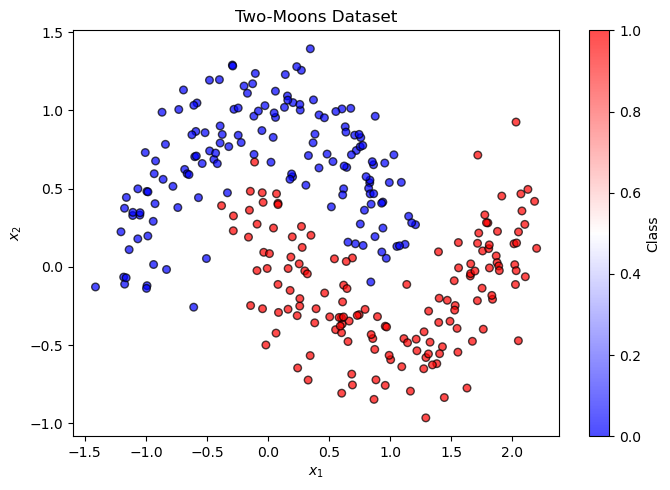

Training set:   240 samples
Validation set: 60 samples


In [26]:
from src.q1a import main as main_q1a

# Q1a: generate data and scatter plot
dataset = main_q1a(
    n_samples=N_SAMPLES, noise=NOISE,
    data_seed=DATA_SEED, split_seed=SPLIT_SEED, test_size=TEST_SIZE,
)

#### Question 1b

In [29]:
from src.q1b import main as main_q1b

y_hat = main_q1b(dataset, layer_sizes=LAYER_SIZES, model_seed=MODEL_SEED)
print(f"Output shape: {y_hat.shape}")
print(f"Output range: [{y_hat.min():.4f}, {y_hat.max():.4f}]")
print(f"All values in (0, 1): {(y_hat > 0).all() and (y_hat < 1).all()}")

Initial cross-entropy loss: 0.6439
y_hat shape: (240, 1) [OK]
Predictions in (0,1): [OK]
Output shape: (240, 1)
Output range: [0.3545, 0.5847]
All values in (0, 1): True


#### Question 1c, backpropagation

In [33]:
from src.q1c import main as main_q1c

max_diff = main_q1c(
    dataset,
    layer_sizes=LAYER_SIZES, model_seed=MODEL_SEED, epsilon=GRADIENT_EPS,
)

Gradient shapes:
dL/dW2      (16, 1)     expected (16, 1)     OK
dL/db2      (1,)        expected (1,)        OK
dL/dW1      (2, 16)     expected (2, 16)     OK
dL/db1      (16,)       expected (16,)       OK

Gradient check (eps = 1e-05, 10 parameters checked)
Max |analytical - numerical|: 8.62e-12

Checked parameters:
linear1.W[0, 0]      analytical= 2.687188e-02 numerical= 2.687188e-02 diff= 2.46e-12
linear1.W[1, 5]      analytical=-2.149000e-02 numerical=-2.149000e-02 diff= 8.21e-12
linear1.W[0, 10]     analytical= 2.511042e-02 numerical= 2.511042e-02 diff= 1.73e-12
linear1.b[0]         analytical= 2.707475e-03 numerical= 2.707475e-03 diff= 4.08e-12
linear1.b[5]         analytical= 2.408909e-03 numerical= 2.408909e-03 diff= 8.62e-12
linear1.b[10]        analytical= 1.886372e-03 numerical= 1.886372e-03 diff= 4.96e-12
linear2.W[0, 0]      analytical=-1.298981e-02 numerical=-1.298981e-02 diff= 5.18e-12
linear2.W[5, 0]      analytical=-8.872372e-03 numerical=-8.872372e-03 diff= 5.74e-1

#### Question 1d, training the network

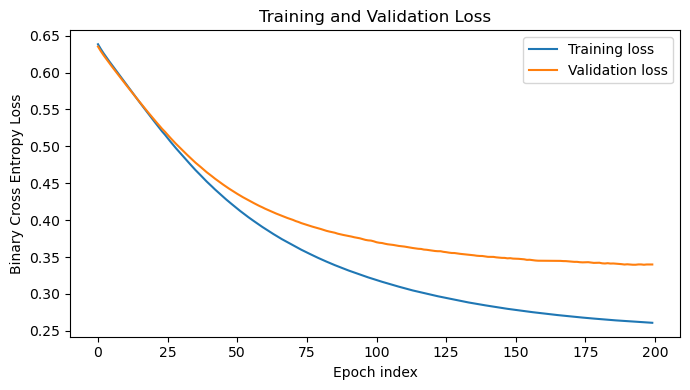

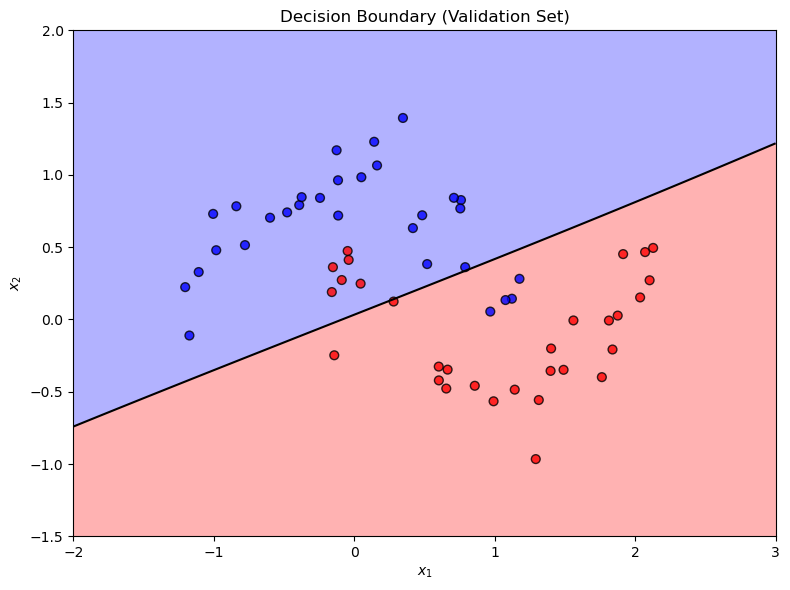


Final training loss:   0.2608
Final validation loss: 0.3399
Final validation accuracy: 83.33%


In [25]:
from src.q1d import main as main_q1d

results = main_q1d(
    dataset,
    LAYER_SIZES, 
    MODEL_SEED,
    LEARNING_RATE, 
    BATCH_SIZE,
    EPOCHS,
    TRAIN_SEED,
)